In [227]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import matplotlib
matplotlib.rcParams.update({'font.size': 10, 'text.usetex': True, 'font.family': 'serif', 'font.serif': ['Computer Modern'], 'figure.figsize': (10,10)})
from scipy import linalg as la

from koala.chern_number import crosshair_marker
from koala import plotting as pl
from koala import graph_utils as gu
from koala.pointsets import uniform
from koala.graph_color import color_lattice
from koala.voronization import generate_lattice
from koala.hamiltonian import majorana_hamiltonian
from koala.flux_finder import fluxes_from_ujk, ujk_from_fluxes
from koala.lattice import cut_boundaries, Lattice
from mpire import WorkerPool


def open_plaquette_flip(lattice:Lattice, plaquette_index:int, ujk: np.ndarray):
    plaq_pos = lattice.plaquettes[plaquette_index].center
    x = plaq_pos[0]
    y = plaq_pos[1]

    vertices_left_of_line = (lattice.vertices.positions[:,0] < x)
    upper_quadrant = (lattice.vertices.positions[:,1] > y)
    edges_crossing = vertices_left_of_line[lattice.edges.indices]
    edges_crossing = (edges_crossing.sum(axis=1) == 1)*upper_quadrant[lattice.edges.indices[:,0]]
    ujk_out = ujk.copy()
    ujk_out[edges_crossing] *= -1
    return ujk_out

In [228]:
points = uniform(4000)
lattice = generate_lattice(points)
lattice = gu.lloyd_relaxation(lattice)

lattice = cut_boundaries(lattice)
lattice = gu.remove_trailing_edges(lattice)


In [293]:
ujk = ujk_from_fluxes(lattice, -np.ones(lattice.n_plaquettes))
fluxes = fluxes_from_ujk(lattice, ujk)

x = np.where(fluxes == 1)[0]
print(x)
ujk_new = open_plaquette_flip(lattice,x[0],ujk )
fluxes = fluxes_from_ujk(lattice, ujk_new)
print(np.where(fluxes == 1)[0])
if len(np.where(fluxes == 1)[0]) == 0:
    print("no fluxes")
    ujk = ujk_new

j = np.array([1,1,1])
coloring = color_lattice(lattice)

[3855]
[]
no fluxes


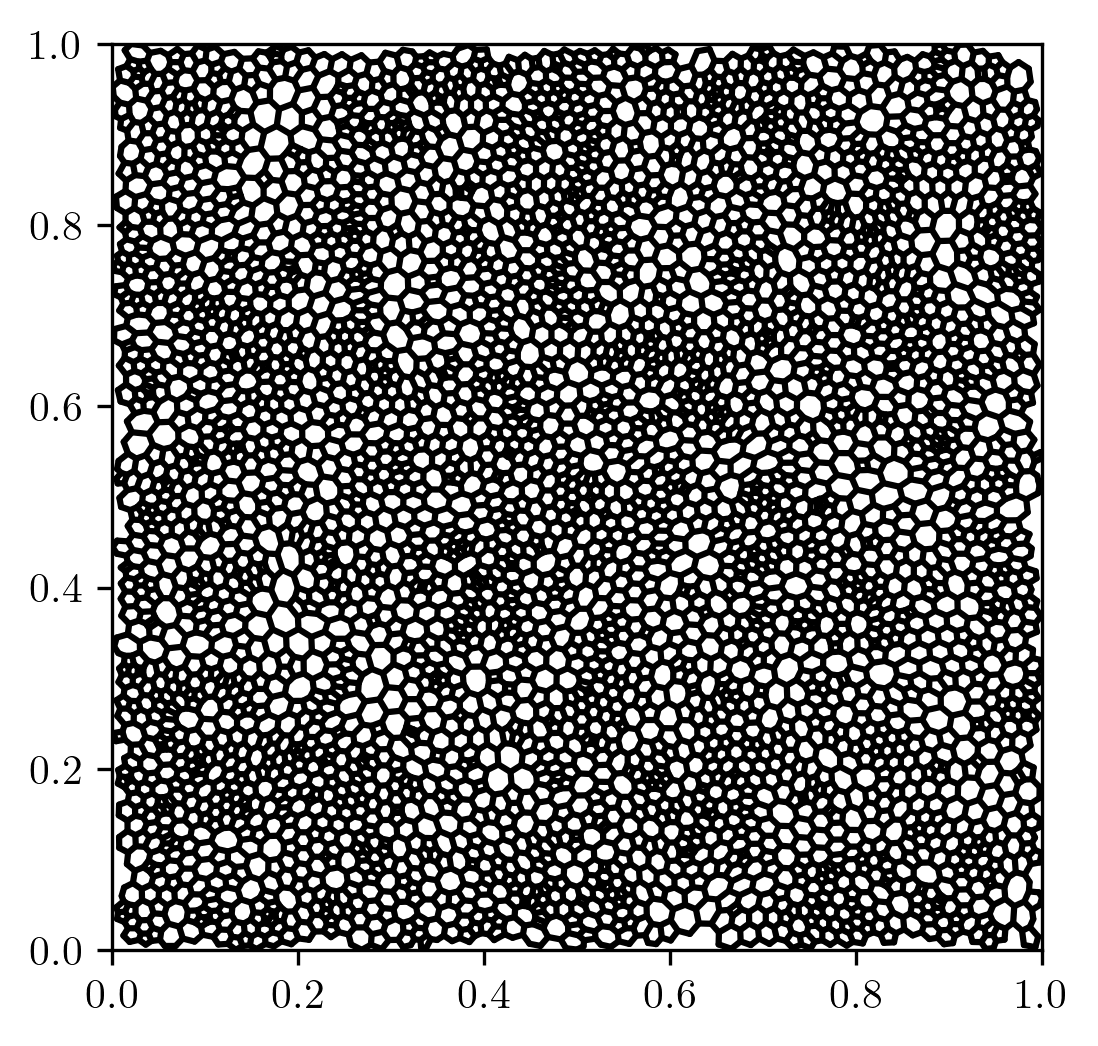

In [294]:

fig, ax = plt.subplots(1,1,figsize=(4, 4), dpi = 300)
pl.plot_edges(lattice)
pl.plot_plaquettes(lattice, fluxes, color_scheme=['r','b','w'])
plt.show()

In [295]:
ham = majorana_hamiltonian(lattice,coloring, ujk, j )
e, v = la.eigh(ham)
projector = v * (e<0) @ v.T.conj()
cmarker = crosshair_marker(lattice, projector, [0.5,0.5])

-0.9999945840714064


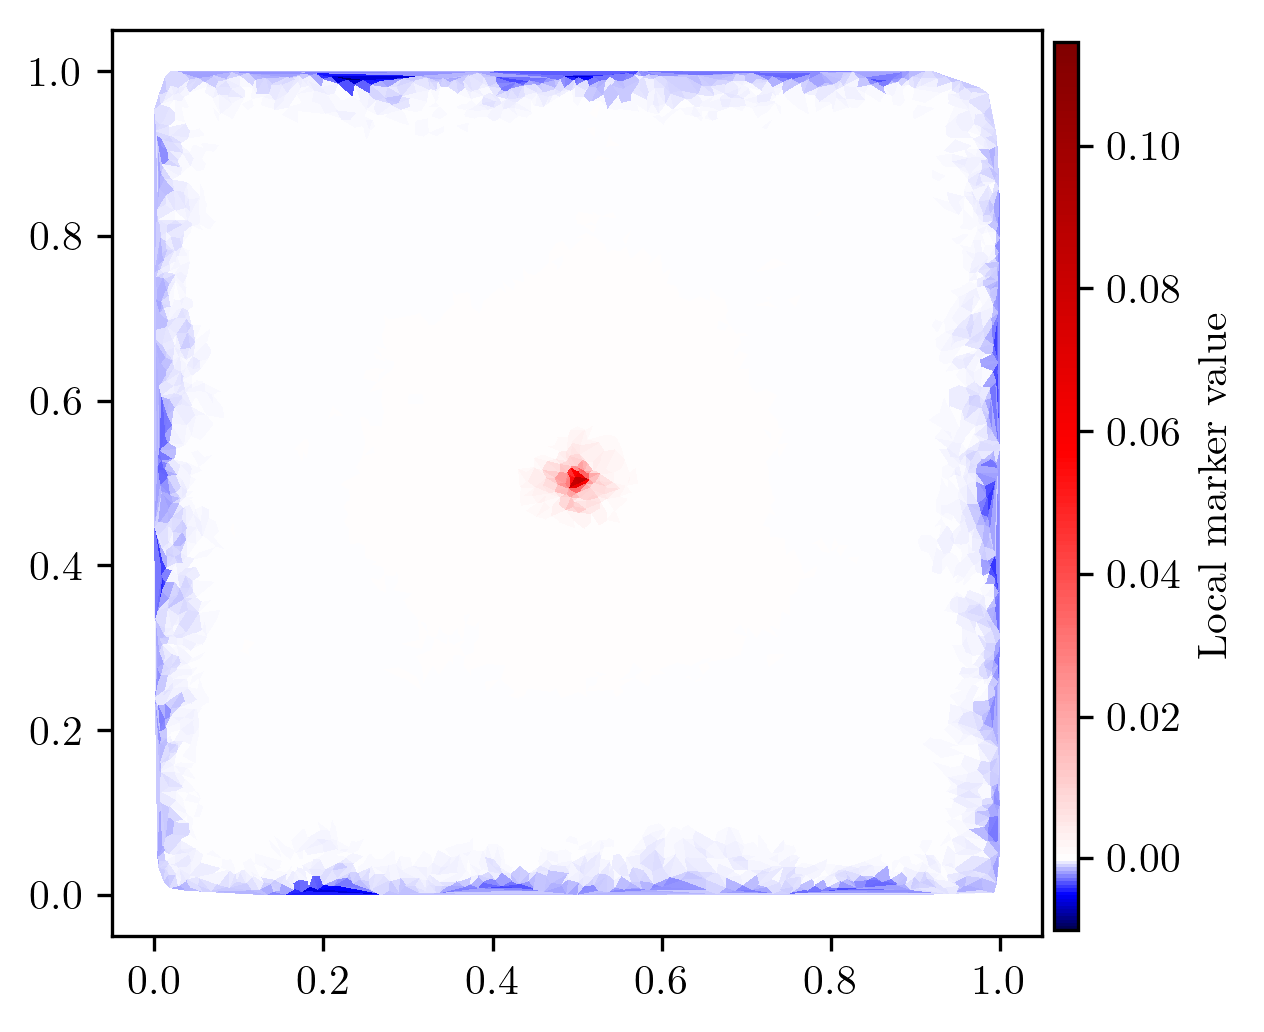

In [378]:
import matplotlib.colors as colors
x_vals = lattice.vertices.positions[:,0]
y_vals = lattice.vertices.positions[:,1]
z_vals = -cmarker
divnorm = colors.TwoSlopeNorm(vmin=np.min(z_vals), vcenter=0, vmax=np.max(z_vals))

fig, ax = plt.subplots(1,1,figsize=(4, 4), dpi = 300)
# pl.plot_edges(lattice)
pcm = ax.tripcolor(x_vals, y_vals, z_vals, norm= divnorm, cmap= 'seismic', rasterized=True)

print(np.sum(cmarker*((0.25<x_vals)*(x_vals<0.75)*(0.25<y_vals)*(y_vals<0.75))))



fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.91, 0.13, 0.02, 0.74 ])
fig.colorbar(pcm, cax=cbar_ax,label = 'Local marker value')
# plt.savefig('edge_mode_1.pdf', bbox_inches='tight')
plt.show()

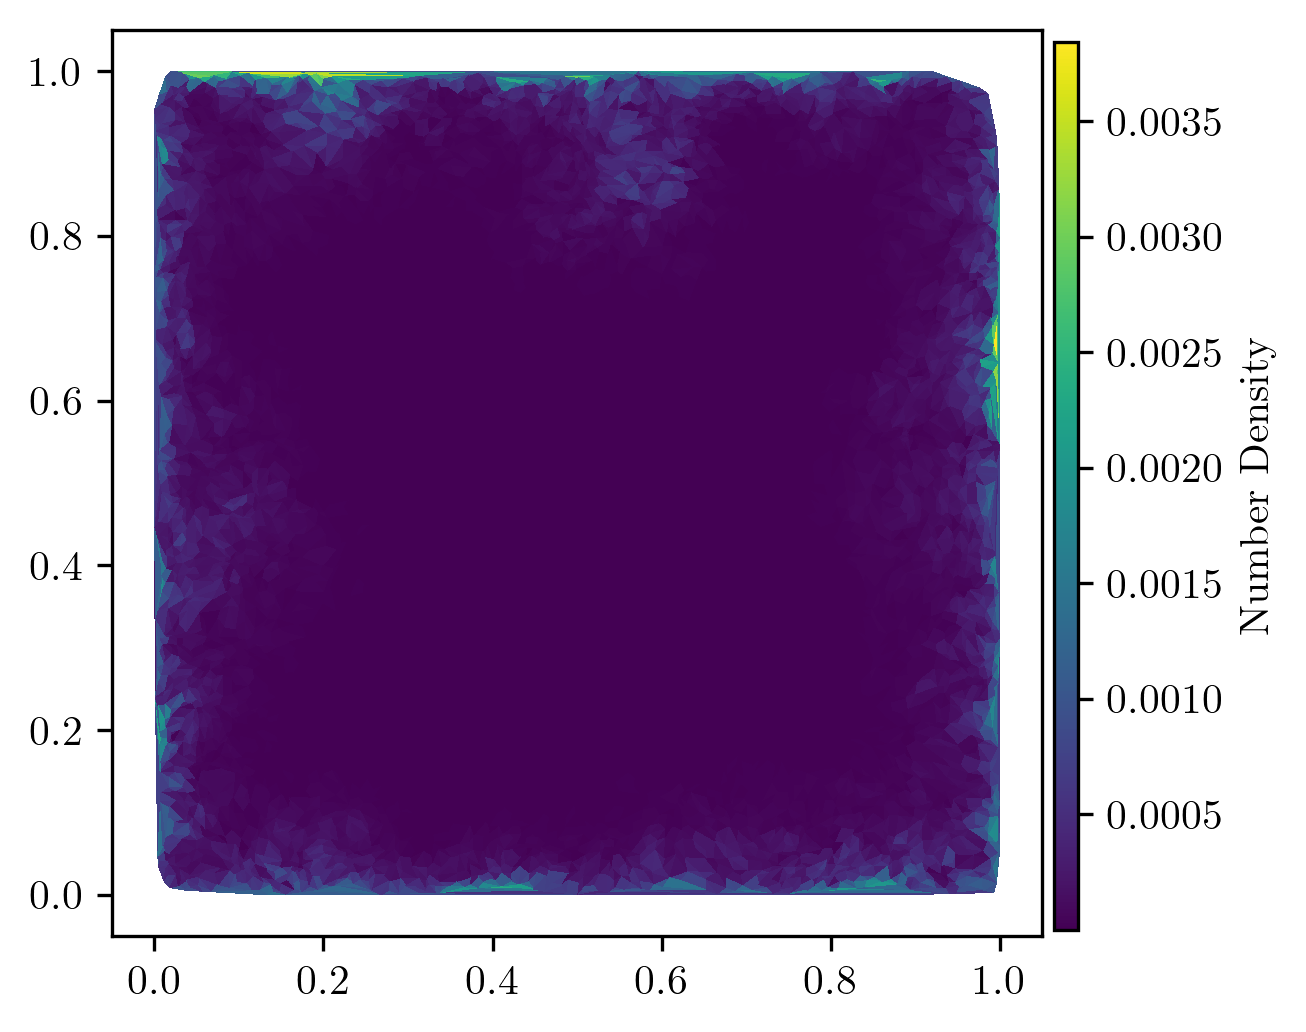

In [368]:
# plot an edge mode

x_vals = lattice.vertices.positions[:,0]
y_vals = lattice.vertices.positions[:,1]
# z_vals = np.log(np.abs(v[:,lattice.n_vertices//2]**2))
z_vals = np.abs(v[:,lattice.n_vertices//2+15]**2)
# divnorm = colors.TwoSlopeNorm(vmin=np.min(z_vals), vcenter=0, vmax=np.max(z_vals))

fig, ax = plt.subplots(1,1,figsize=(4, 4), dpi = 300)
# pl.plot_edges(lattice)
pcm = ax.tripcolor(x_vals, y_vals, z_vals, cmap= 'viridis', rasterized=True)

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.91, 0.13, 0.02, 0.74 ])
fig.colorbar(pcm, cax=cbar_ax,label = 'Number Density')
plt.savefig('edge_mode_2_no_log.pdf', bbox_inches='tight')
plt.show()

In [354]:
# plot dos
from matplotlib import colorbar
import scipy
n_bins = 401
ipr_values = np.sum(np.abs(v)**4, axis=0)
hist, bin_edges = np.histogram(e, bins=n_bins)
state_counts = np.array([np.sum(bin_edges<energy) for energy in e])
ipr_averages = np.log10([np.mean(ipr_values[state_counts == n]) for n in range(n_bins)])
norm = colors.Normalize(vmin=np.min(ipr_averages), vmax=np.max(ipr_averages)-0.4)
colours = plt.cm.viridis(norm(ipr_averages))


In [355]:

pos = lattice.vertices.positions
d_from_p1 = np.linalg.norm(pos - np.array([0,0.5]),axis = 1)
d_from_p2 = np.linalg.norm(pos - np.array([1,0.5]),axis = 1)

point1 = np.argmin(d_from_p1)
point2 = np.argmin(d_from_p2)
D, Pr = scipy.sparse.csgraph.shortest_path(lattice.adjacency_matrix, directed=False, method='FW', return_predecessors=True)

def get_path(Pr, i, j):
    path = [j]
    k = j
    while Pr[i, k] != -9999:
        path.append(Pr[i, k])
        k = Pr[i, k]
    return path[::-1]



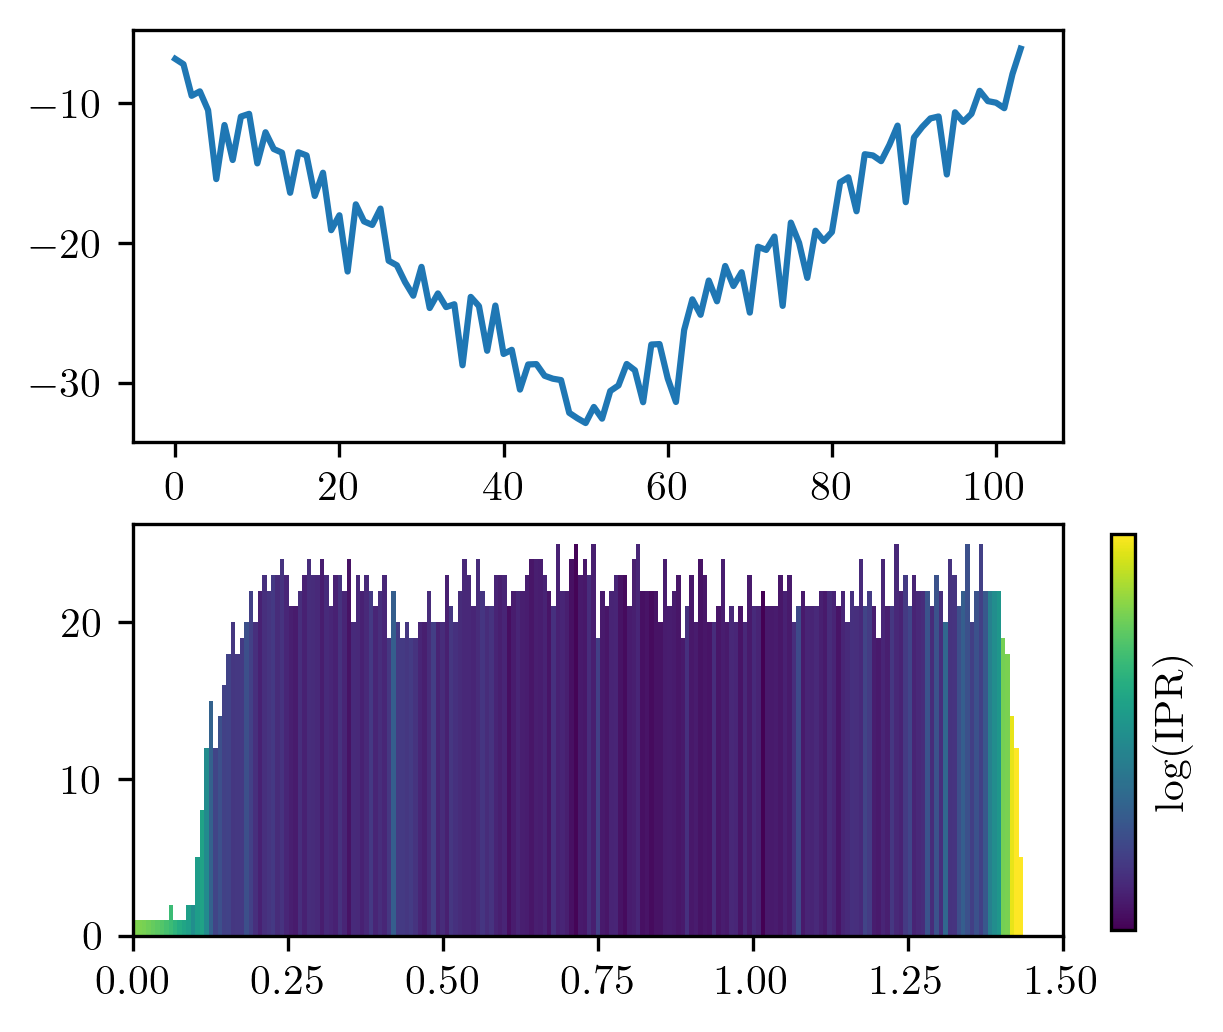

In [356]:
path = np.array(get_path(Pr,point1,point2))


fig, ax = plt.subplots(2,1,figsize=(4, 4), dpi = 300)
ax[0].plot(np.log(np.abs(v[:,lattice.n_vertices//2]**2))[path])
ax[1].bar(bin_edges[:-1], hist, width = (bin_edges[1]-bin_edges[0]), color=colours)
ax[1].set_xlim(0,1.5)
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.94, 0.13, 0.02, 0.33 ])
cb1 = colorbar.ColorbarBase(cbar_ax, cmap=plt.cm.viridis, norm=norm,ticks=[],label = 'log(IPR)')
plt.savefig('edge_mode_3.pdf', bbox_inches='tight')
plt.show()



In [381]:
e[lattice.n_vertices//2-1]

-0.003332268352948864